**Name**: Devyani Sanjay Gurgude **Div**: SEDA **Roll**: 09 **PRN no**:1252090009


**Assignment No:06**

Use the diabetes data set from UCI and Pima Indians Diabetes data set for performing the following:

a. Univariate analysis: Frequency, Mean, Median, Mode, Variance, Standard Deviation,
Skewness and Kurtosis

b. Bivariate analysis: Linear and logistic regression modeling

c. Multiple Regression analysis

d. Also compare the results of the above analysis for the two data sets.

Dataset link: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database

In [ ]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix , precision_score

df=pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


a. Univariate analysis: Frequency, Mean, Median, Mode, Variance, Standard Deviation, Skewness and Kurtosis

In [ ]:
print("Mean:\n",df.mean())
print("Median:\n",df.median())
print("Mode:\n",df.mode())
print("Variance:\n",df.var())
print("Standard Deviation:\n",df.std())
print("Skewness:\n",df.skew())
print("Kurtosis:\n",df.kurt())

Mean:
 Pregnancies                   3.845052
Glucose                     120.894531
BloodPressure                69.105469
SkinThickness                20.536458
Insulin                      79.799479
BMI                          31.992578
DiabetesPedigreeFunction      0.471876
Age                          33.240885
Outcome                       0.348958
dtype: float64
Median:
 Pregnancies                   3.0000
Glucose                     117.0000
BloodPressure                72.0000
SkinThickness                23.0000
Insulin                      30.5000
BMI                          32.0000
DiabetesPedigreeFunction      0.3725
Age                          29.0000
Outcome                       0.0000
dtype: float64
Mode:
    Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0          1.0       99           70.0            0.0      0.0  32.0   
1          NaN      100            NaN            NaN      NaN   NaN   

   DiabetesPedigreeFunction   Age  Outcome  
0

Linear Regression (Single Feature)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

X = df[["Age"]]
y = df["BMI"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Coefficient:", model.coef_)
print("Intercept:", model.intercept_)
print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


Coefficient: [0.0029963]
Intercept: 31.88478783786934
R2 Score: 0.0012290314419062254
MSE: 70.99807860058112
RMSE: 8.426035758325568


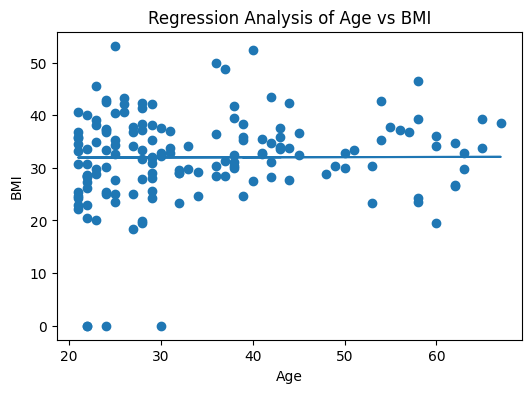

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred)
plt.xlabel("Age")
plt.ylabel("BMI")
plt.title("Regression Analysis of Age vs BMI")
plt.show()

Logistic Regression (Single Feature)

In [ ]:
X = df[["Glucose"]]
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.7229437229437229
Precision: 0.6290322580645161
Recall: 0.4875
F1 Score: 0.5492957746478874
Accuracy: 0.7229437229437229
Confusion Matrix:
 [[128  23]
 [ 41  39]]


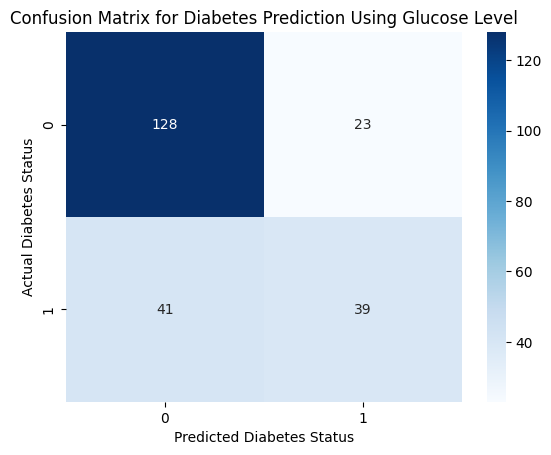

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Diabetes Status")
plt.ylabel("Actual Diabetes Status")
plt.title("Confusion Matrix for Diabetes Prediction Using Glucose Level")
plt.show()

Linear Regression (Multiple Feature)


In [ ]:
X = df[["BMI", "Age", "Pregnancies"]]
y = df["Glucose"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MSE:", mean_squared_error(y_test, y_pred))



Intercept: 68.66767203592693
Coefficients: [ 0.86024982  0.76729089 -0.18873411]
R2 Score: 0.1173953583962768
RMSE: 29.221615238632648
MSE: 853.9027971546878


/tmp/ipython-input-215/3238162061.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


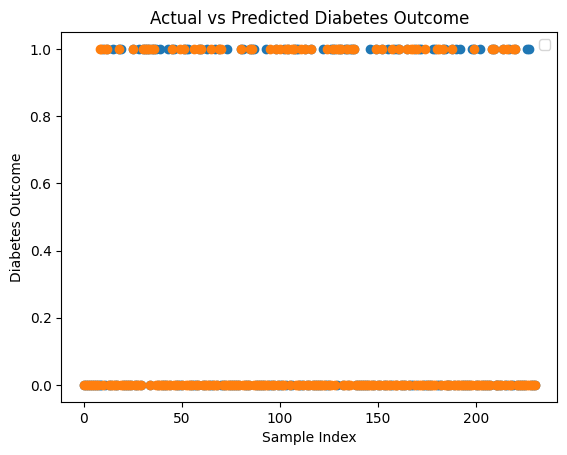

In [ ]:
plt.scatter(range(len(y_test)), y_test)
plt.scatter(range(len(y_test)), y_pred)

plt.xlabel("Sample Index")
plt.ylabel("Diabetes Outcome")
plt.title("Actual vs Predicted Diabetes Outcome")
plt.legend()
plt.show()

Logistic Regression (Multiple Features)

In [ ]:
X = df[["Glucose", "BMI", "Age"]]
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.7467532467532467
Confusion Matrix:
 [[80 19]
 [20 35]]
Accuracy: 0.7467532467532467
Precision: 0.6481481481481481
Recall: 0.6363636363636364
F1 Score: 0.6422018348623854


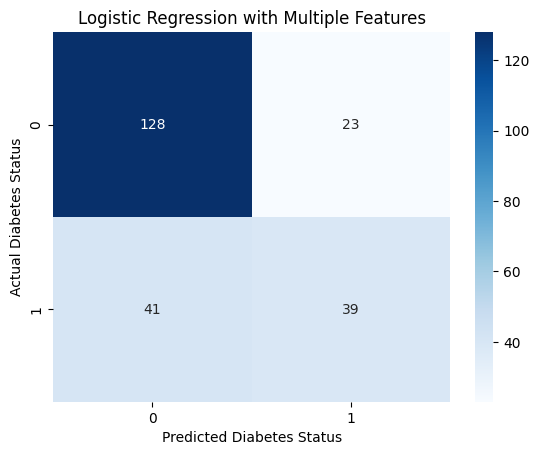

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Diabetes Status")
plt.ylabel("Actual Diabetes Status")
plt.title("Logistic Regression with Multiple Features")
plt.show()

Sklearn Dataset

In [ ]:
diabetes = load_diabetes()
sk_df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
sk_df['target'] = diabetes.target

print("Sklearn Diabetes Shape:", sk_df.shape)
print(sk_df.head())

Sklearn Diabetes Shape: (442, 11)
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  


In [ ]:
print("Mean:\n",sk_df.mean())
print("Median:\n",sk_df.median())
print("Mode:\n",sk_df.mode().loc[0])
print("Variance:\n",sk_df.var())
print("Standard Deviation:\n",sk_df.std())
print("Skewness:\n",sk_df.skew())
print("Kurtosis:\n",sk_df.kurt())

Mean:
 age      -1.444295e-18
sex       2.543215e-18
bmi      -2.255925e-16
bp       -4.854086e-17
s1       -1.428596e-17
s2        3.898811e-17
s3       -6.028360e-18
s4       -1.788100e-17
s5        9.243486e-17
s6        1.351770e-17
target    1.521335e+02
dtype: float64
Median:
 age         0.005383
sex        -0.044642
bmi        -0.007284
bp         -0.005670
s1         -0.004321
s2         -0.003819
s3         -0.006584
s4         -0.002592
s5         -0.001947
s6         -0.001078
target    140.500000
dtype: float64
Mode:
 age        0.016281
sex       -0.044642
bmi       -0.030996
bp        -0.040099
s1        -0.037344
s2        -0.001001
s3        -0.013948
s4        -0.039493
s5        -0.018114
s6         0.003064
target    72.000000
Name: 0, dtype: float64
Variance:
 age          0.002268
sex          0.002268
bmi          0.002268
bp           0.002268
s1           0.002268
s2           0.002268
s3           0.002268
s4           0.002268
s5           0.002268
s6        

Bivariate Linear Regression

In [ ]:
X = sk_df[['bmi']]
y = sk_df['target']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Coefficient:",model.coef_)
print("Intercept:",model.intercept_)
print("R2 score:",r2_score(y_test,y_pred))
print("MSE:",mean_squared_error(y_test,y_pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred)))


Coefficient: [988.41931249]
Intercept: 151.04202449316014
R2 score: 0.2803417492440603
MSE: 3884.936720961032
RMSE: 62.32926055201547


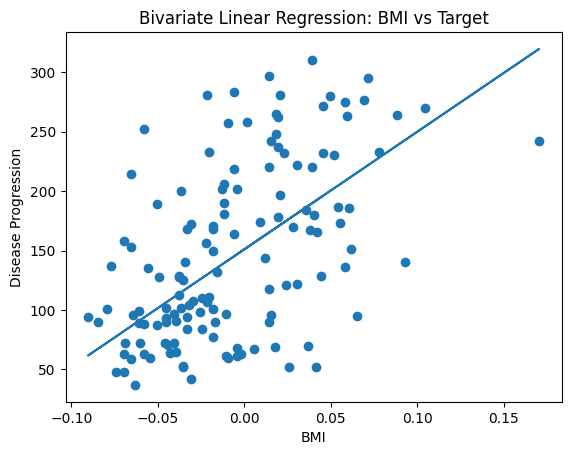

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred)
plt.xlabel("BMI")
plt.ylabel("Disease Progression")
plt.title("Bivariate Linear Regression: BMI vs Target")
plt.show()